# Bibliotekos

In [121]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.manifold import TSNE

from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

from sklearn.linear_model import LassoCV

from sklearn.cluster import KMeans

# Duomenų paruošimas

In [3]:
file_path = os.path.join("..", "1_laboratorinis", "loan_data.csv")
data = pd.read_csv(file_path)

cols_to_factor = ['credit.policy', 'not.fully.paid', 'purpose']
for col in cols_to_factor:
    data[col] = data[col].astype('category')

data['annual.inc'] = np.exp(data['log.annual.inc'])

print(f"Eilučių skaičius: {len(data)}")
print(f"Stulpelių skaičius: {len(data.columns)}")

Eilučių skaičius: 9578
Stulpelių skaičius: 15


In [4]:
sampled_data = data.groupby(['purpose', 'credit.policy'], observed=False).sample(
    frac=0.4, 
    random_state=6202
).reset_index(drop=True)

print(f"\nAtrinktų duomenų dydis: {len(sampled_data)}")


Atrinktų duomenų dydis: 3832


In [5]:
purpose_translations = {
    'debt_consolidation': 'Skolų konsolidavimas',
    'credit_card': 'Kredito kortelė',
    'all_other': 'Kita',
    'home_improvement': 'Namų remontas',
    'small_business': 'Smulkus verslas',
    'major_purchase': 'Svarbus pirkinys',
    'educational': 'Edukacija'
}

# Normavimas

In [84]:
def min_max_normalization(x):
    return (x - x.min()) / (x.max() - x.min())

def denormalize(df_norm, orig_min, orig_max):
    return df_norm * (orig_max - orig_min) + orig_min

numeric_cols = sampled_data.select_dtypes(include=[np.number])

orig_min = numeric_cols.min()
orig_max = numeric_cols.max()

min_max_data = numeric_cols.apply(min_max_normalization)

min_max_data  = min_max_data.drop(['int.rate', 'installment', 'log.annual.inc'], axis=1)

categorical_cols = sampled_data.select_dtypes(exclude=[np.number])
full_min_max_data = pd.concat([min_max_data, categorical_cols], axis=1)

min_max_data.head()

,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,annual.inc
0,0.088433,0.404762,0.252568,0.006169,0.901408,0.000000,0.0,0.0,0.015173
1,0.034633,0.285714,0.199361,0.009275,0.413146,0.148148,0.0,0.0,0.049939
2,0.504371,0.214286,0.000000,0.000000,0.448826,0.037037,0.0,0.0,0.000344
3,0.336247,0.333333,0.218260,0.000000,0.203756,0.148148,0.0,0.0,0.086767
4,0.187962,0.547619,0.408971,0.011692,0.646948,0.222222,0.0,0.0,0.050030


In [7]:
full_min_max_data.to_csv('full_min_max_data.csv', index=False)

# t-SNE

In [8]:
tsne = TSNE(n_components=2, random_state=42, perplexity=50, learning_rate=500, max_iter=2000, early_exaggeration=4)
tsne_results = tsne.fit_transform(min_max_data)

In [9]:
tsne_df = pd.DataFrame(tsne_results, columns=['tsne_1', 'tsne_2'])
tsne_df.head()

,tsne_1,tsne_2
0,26.360550,-36.467628
1,-20.327391,-36.450569
2,7.374322,8.128087
3,-7.246502,3.627963
4,8.907294,-32.525677


In [10]:
tsne_df.to_csv('tsne_data.csv', index=False)

# Požymių atrinkimas

## RFE

In [11]:
filtered_data = full_min_max_data[full_min_max_data['purpose'] != 'all_other']

top_3_purposes = filtered_data['purpose'].value_counts().nlargest(3).index.tolist()

print(f"Trys dažniausios grupės: {top_3_purposes}")

debt_consolidation_data = full_min_max_data[full_min_max_data['purpose'] == top_3_purposes[0]]
credit_card_data = full_min_max_data[full_min_max_data['purpose'] == top_3_purposes[1]]
home_improvement_data = full_min_max_data[full_min_max_data['purpose'] == top_3_purposes[2]]

Trys dažniausios grupės: ['debt_consolidation', 'credit_card', 'home_improvement']



Skolų konsolidavimas:
Optimalus požymių skaičius: 8
Geriausi požymiai: ['dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths', 'pub.rec', 'annual.inc']

Kredito kortelė:
Optimalus požymių skaičius: 2
Geriausi požymiai: ['fico', 'inq.last.6mths']

Namų remontas:
Optimalus požymių skaičius: 5
Geriausi požymiai: ['dti', 'fico', 'days.with.cr.line', 'revol.bal', 'inq.last.6mths']


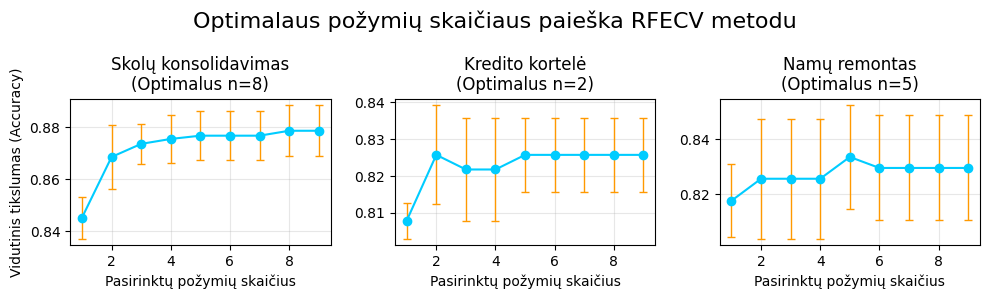

In [31]:
groups = [debt_consolidation_data, credit_card_data, home_improvement_data]
titles = ["Skolų konsolidavimas", "Kredito kortelė", "Namų remontas"]
file_names = ["rfecv_debt_consolidation.csv", "rfecv_credit_card.csv", "rfecv_home_improvement.csv"]

plt.figure(figsize=(10, 3))

for i, df in enumerate(groups):
    y = df['credit.policy']
    X = df.drop(columns=['credit.policy', 'purpose'], errors='ignore').select_dtypes(include=[np.number])
    
    clf = LogisticRegression(max_iter=2000, solver='liblinear')
    cv = StratifiedKFold(5)
    
    rfecv = RFECV(
        estimator=clf,
        step=1,
        cv=cv,
        scoring="accuracy",
        min_features_to_select=1,
        n_jobs=-1
    )
    
    rfecv.fit(X, y)

    selected_features = list(X.columns[rfecv.support_])
    
    print(f"\n{titles[i]}:")
    print(f"Optimalus požymių skaičius: {rfecv.n_features_}")
    print(f"Geriausi požymiai: {selected_features}")

    output_df = df[selected_features + ['credit.policy']].copy()
    output_df.to_csv(file_names[i], index=False)
    
    plt.subplot(1, 3, i + 1)

    cv_res = pd.DataFrame({
        "n_features": rfecv.cv_results_["n_features"],
        "mean_test_score": rfecv.cv_results_["mean_test_score"],
        "std_test_score": rfecv.cv_results_["std_test_score"]
    })
    
    plt.errorbar(
        x=cv_res["n_features"],
        y=cv_res["mean_test_score"],
        yerr=cv_res["std_test_score"],
        fmt='-o', color='#00CCFF', ecolor='#FF9900', capsize=3, elinewidth=1, markeredgewidth=1
    )
    
    plt.title(f"{titles[i]}\n(Optimalus n={rfecv.n_features_})")
    plt.xlabel("Pasirinktų požymių skaičius")
    if i == 0: plt.ylabel("Vidutinis tikslumas (Accuracy)")
    plt.grid(alpha=0.3)

plt.suptitle("Optimalaus požymių skaičiaus paieška RFECV metodu", fontsize=16)
plt.tight_layout()
plt.show()

## LassoCV

In [13]:
debt_consolidation_data.head()

,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,annual.inc,credit.policy,purpose,not.fully.paid
1437,0.887693,0.380952,0.209670,0.013196,0.388732,0.074074,0.000000,0.0,0.020476,0,debt_consolidation,0
1438,0.437794,0.333333,0.111737,0.024302,0.312676,0.148148,0.000000,0.0,0.016794,0,debt_consolidation,1
1439,0.656355,0.261905,0.249184,0.021710,0.311737,0.148148,0.166667,0.0,0.017039,0,debt_consolidation,0
1440,0.544385,0.261905,0.353991,0.014127,0.781221,0.148148,0.000000,0.0,0.028333,0,debt_consolidation,0
1441,0.891728,0.238095,0.142833,0.054771,0.615023,0.148148,0.000000,0.0,0.025485,0,debt_consolidation,0


In [14]:
debt_consolidation_data = debt_consolidation_data.drop(columns=['purpose'])
credit_card_data = credit_card_data.drop(columns=['purpose'])
home_improvement_data = home_improvement_data.drop(columns=['purpose'])

--- GRUPĖ: Skolų konsolidavimas ---
Svarbiausių požymių kiekis: 3
Atmesti požymiai: ['days.with.cr.line', 'revol.bal', 'revol.util', 'delinq.2yrs', 'pub.rec', 'annual.inc']

--- GRUPĖ: Kredito kortelė ---
Svarbiausių požymių kiekis: 2
Atmesti požymiai: ['DTI', 'days.with.cr.line', 'revol.bal', 'revol.util', 'delinq.2yrs', 'pub.rec', 'annual.inc']

--- GRUPĖ: Namų remontas ---
Svarbiausių požymių kiekis: 3
Atmesti požymiai: ['days.with.cr.line', 'revol.bal', 'revol.util', 'delinq.2yrs', 'pub.rec', 'annual.inc']



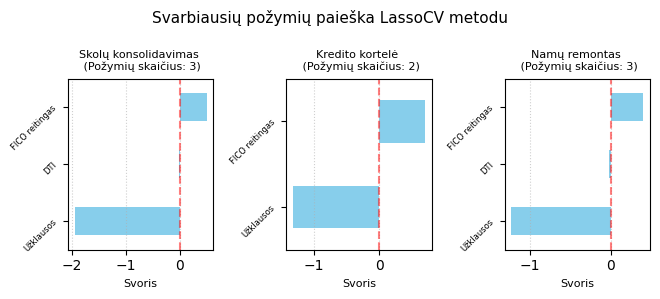

In [30]:
translations = {
    'dti': 'DTI',
    'fico': 'FICO reitingas',
    'inq.last.6mths': 'Užklausos'
}

purposes_list = [
    (debt_consolidation_data, "Skolų konsolidavimas"),
    (credit_card_data, "Kredito kortelė"),
    (home_improvement_data, "Namų remontas")
]

file_names = ["LassoCV_debt_consolidation.csv", "LassoCV_credit_card.csv", "LassoCV_home_improvement.csv"]


fig, axes = plt.subplots(1, 3, figsize=(6.7, 3))

for i, (df, title) in enumerate(purposes_list):
    
    X = df.drop(columns=['credit.policy', 'not.fully.paid'])
    y = df['credit.policy']

    lasso = LassoCV(cv=5, random_state=2026, max_iter=10000).fit(X, y)
    
    translated_index = [translations.get(col, col) for col in X.columns]
    coef = pd.Series(lasso.coef_, index=translated_index)

    orig_coef = pd.Series(lasso.coef_, index=X.columns)
    important_orig = orig_coef[orig_coef != 0].index.tolist()
    df_filtered = df[important_orig + ['credit.policy']].copy()
    df_filtered.to_csv(file_names[i], index=False)
    
    imp_coef = coef[coef != 0].sort_values()

    if not imp_coef.empty:
        imp_coef.plot(kind="barh", ax=axes[i], color='skyblue')
        axes[i].set_title(f"{title} \n (Požymių skaičius: {len(imp_coef)})", fontsize=8)
        axes[i].axvline(x=0, color='red', linestyle='--', alpha=0.5)
        axes[i].grid(True, axis='x', linestyle=':', alpha=0.6)
    else:
        axes[i].text(0.5, 0.5, "Reikšmingų požymių nerasta", ha='center')
        axes[i].set_title(title, fontsize=8)

    axes[i].set_xlabel("Svoris", fontsize=8)
    axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=6, rotation=45)


    rejected = coef[coef == 0].index.tolist()
    print(f"--- GRUPĖ: {title} ---")
    print(f"Svarbiausių požymių kiekis: {len(imp_coef)}")
    print(f"Atmesti požymiai: {rejected}\n")

plt.suptitle("Svarbiausių požymių paieška LassoCV metodu", fontsize=11)
plt.tight_layout()
plt.savefig('lasso.png', dpi=300)
plt.show()

# Aprašomoji statistika

In [90]:
clustered_debt_consolidation = pd.read_csv('clustered_debt_consolidation.csv')
clustered_credit_card = pd.read_csv('clustered_credit_card.csv')
clustered_home_improvement = pd.read_csv('clustered_home_improvement.csv')

In [106]:
purposes = ['debt_consolidation', 'credit_card', 'home_improvement']

def prepare_and_denorm(purpose_name):
    subset = sampled_data[sampled_data['purpose'] == purpose_name].copy()
    subset = subset.rename(columns={'credit.policy': 'label'}).drop(columns=['purpose'])
    
    cols_to_fix = subset.select_dtypes(include=[np.number]).columns.drop('label', errors='ignore')
    
    subset[cols_to_fix] = subset[cols_to_fix] * (orig_max[cols_to_fix] - orig_min[cols_to_fix]) + orig_min[cols_to_fix]
    
    return subset

dfs = {p: prepare_and_denorm(p) for p in purposes}

data_w_clusters_debt = dfs['debt_consolidation'].reset_index()
data_w_clusters_credit = dfs['credit_card'].reset_index()
data_w_clusters_home = dfs['home_improvement'].reset_index()

data_w_clusters_debt['label'] = clustered_debt_consolidation['cluster']
data_w_clusters_credit['label'] = clustered_credit_card['cluster']
data_w_clusters_home['label'] = clustered_home_improvement['cluster']

In [ ]:
def get_characteristic_table(df, group_col='label'):
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if group_col in numeric_cols:
        numeric_cols.remove(group_col)
    
    char_table = df.groupby(group_col, observed=False)[numeric_cols].agg([
        'mean', 
        'var', 
        'std', 
        'min', 
        lambda x: x.quantile(0.25), # Q1
        'median', 
        lambda x: x.quantile(0.75), # Q3
        'max'
    ])
    
    char_table.columns = char_table.columns.set_levels(
        ['Vidurkis', 'Variancija', 'SD', 'Min', 'Q1', 'Mediana', 'Q3', 'Max'], level=1
    )
    
    return char_table.T

In [ ]:
get_characteristic_table(data_w_clusters_debt.drop(columns='index'))

label                             0             1
int.rate   Vidurkis    8.009915e-02  7.829018e-02
           Variancija  1.285409e-05  1.420230e-05
           SD          3.585261e-03  3.768594e-03
           Min         7.125540e-02  7.028196e-02
           Q1          7.799343e-02  7.533168e-02
...                             ...           ...
annual.inc Min         2.443781e+10  2.036484e+10
           Q1          7.942288e+10  8.145936e+10
           Mediana     1.058972e+11  1.120066e+11
           Q3          1.527363e+11  1.629187e+11
           Max         6.565624e+11  4.153988e+12

[96 rows x 2 columns]

In [116]:
get_characteristic_table(data_w_clusters_credit.drop(columns='index'))

label                             0             1
int.rate   Vidurkis    8.053458e-02  7.562914e-02
           Variancija  8.141387e-06  6.428283e-06
           SD          2.853312e-03  2.535406e-03
           Min         6.912600e-02  7.028196e-02
           Q1          7.869309e-02  7.359774e-02
...                             ...           ...
annual.inc Min         2.036484e+10  1.731012e+10
           Q1          8.629601e+10  8.960530e+10
           Mediana     1.262620e+11  1.221890e+11
           Q3          1.833854e+11  1.722866e+11
           Max         1.018242e+12  6.109452e+11

[96 rows x 2 columns]

In [117]:
get_characteristic_table(data_w_clusters_home.drop(columns='index'))

label                             0             1
int.rate   Vidurkis    7.581660e-02  7.979867e-02
           Variancija  1.175989e-05  1.209371e-05
           SD          3.429270e-03  3.477601e-03
           Min         6.912600e-02  7.168128e-02
           Q1          7.306539e-02  7.799343e-02
...                             ...           ...
annual.inc Min         4.072968e+10  3.054726e+10
           Q1          1.104782e+11  1.034534e+11
           Mediana     1.588458e+11  1.425539e+11
           Q3          2.439749e+11  2.026383e+11
           Max         1.466268e+12  5.702074e+11

[96 rows x 2 columns]

In [132]:
data_w_clusters_home

,index,label,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,annual.inc
0,3158,1,0.078085,447107.8450,81.414410,508.8514,150137.0,1.403866e+08,3.751758e+10,5122.65,27.0,0.0,0.0,0,1.832836e+11
1,3159,0,0.073065,28434.1450,83.263250,358.3670,170087.0,1.073846e+08,1.048943e+11,457.95,0.0,0.0,0.0,0,2.443781e+11
2,3160,0,0.079058,90250.1700,83.263250,103.4952,148037.0,1.335768e+08,1.298899e+08,596.40,108.0,0.0,0.0,0,2.443781e+11
3,3161,1,0.081674,246632.6700,78.249423,461.8622,137537.0,1.518934e+08,7.566672e+09,5442.15,0.0,12.0,0.0,1,1.120066e+11
4,3162,1,0.082541,155400.5575,77.888954,421.4158,135437.0,1.299093e+08,2.082517e+09,4632.75,27.0,12.0,0.0,0,1.058972e+11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,3405,1,0.074176,172297.0575,71.417192,533.5356,155387.0,1.268020e+08,3.485250e+09,4334.55,27.0,0.0,0.0,0,3.868505e+10
248,3406,0,0.078085,596138.5700,78.872564,85.9486,156437.0,6.390744e+07,2.668966e+09,4973.55,108.0,0.0,0.0,1,1.234109e+11
249,3407,0,0.077993,372259.9450,78.249423,31.8218,155387.0,6.233522e+07,7.987842e+08,1214.10,0.0,0.0,0.0,0,1.120066e+11
250,3408,0,0.077993,744495.2325,84.479314,164.7596,163787.0,1.796746e+08,1.209454e+08,42.60,27.0,0.0,0.0,0,2.952841e+11


In [139]:
def plot_2x2_boxplots(df, group_col='label'):
    numeric_cols = df[['fico', 'dti', 'inq.last.6mths', 'annual.inc']].columns.tolist()
    if group_col in numeric_cols:
        numeric_cols.remove(group_col)
    
    features_to_plot = numeric_cols[:4]
    
    fig, axes = plt.subplots(2, 2, figsize=(6.7, 6))
    axes = axes.flatten()
    
    for i, col in enumerate(features_to_plot):
        sns.boxplot(x=group_col, y=col, data=df, ax=axes[i], palette='Set2')
        axes[i].set_title(f'{col}', fontsize=14)
        axes[i].set_xlabel('klusteris', fontsize=10)
        axes[i].set_ylabel(col, fontsize=10)
        axes[i].grid(axis='y', linestyle='--', alpha=0.5)
        
    for j in range(len(features_to_plot), 4):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.savefig('boxplot_2x2_grid.png')
    plt.show()

C:\Users\crist\AppData\Local\Temp\ipykernel_28092\2169245224.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=group_col, y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\crist\AppData\Local\Temp\ipykernel_28092\2169245224.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=group_col, y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\crist\AppData\Local\Temp\ipykernel_28092\2169245224.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=group_col, y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\crist\AppData\Local\Temp\

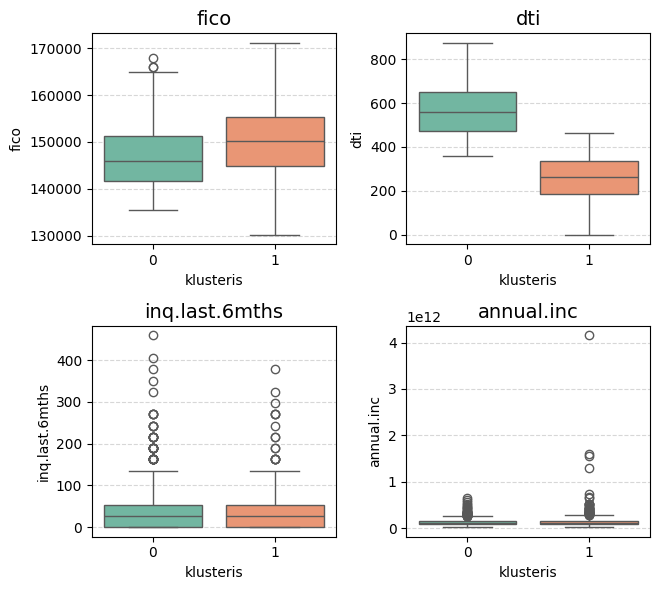

In [140]:
plot_2x2_boxplots(data_w_clusters_debt)

C:\Users\crist\AppData\Local\Temp\ipykernel_28092\2169245224.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=group_col, y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\crist\AppData\Local\Temp\ipykernel_28092\2169245224.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=group_col, y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\crist\AppData\Local\Temp\ipykernel_28092\2169245224.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=group_col, y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\crist\AppData\Local\Temp\

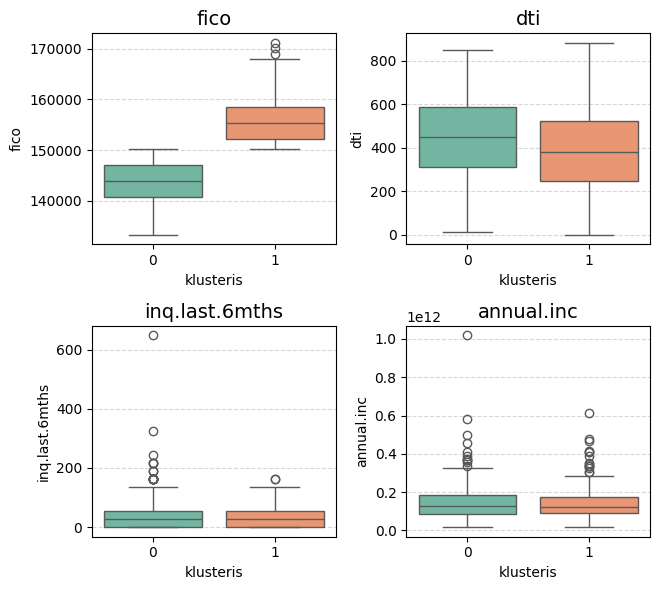

In [141]:
plot_2x2_boxplots(data_w_clusters_credit)

C:\Users\crist\AppData\Local\Temp\ipykernel_28092\2169245224.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=group_col, y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\crist\AppData\Local\Temp\ipykernel_28092\2169245224.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=group_col, y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\crist\AppData\Local\Temp\ipykernel_28092\2169245224.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=group_col, y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\crist\AppData\Local\Temp\

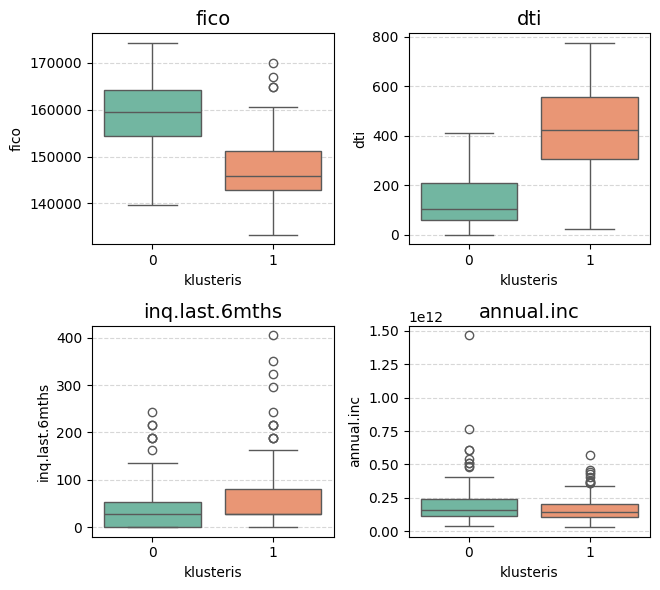

In [142]:
plot_2x2_boxplots(data_w_clusters_home)